# 06 – Preprocessing NTHUDDD2: Face Detection & Eye Cropping via MediaPipe

Tujuan:
- Dataset NTHUDDD2 bawaan masih berupa gambar *full face*.
- Karena model backbone dilatih menggunakan dataset MRL (*crop* mata), kita perlu menyamakan domain.
- Notebook ini menggunakan **MediaPipe Face Mesh** untuk mendeteksi *landmark* wajah pada gambar NTHUDDD2 (hasil *split*).
- Jika terdeteksi, kita potong (crop) area yang mencakup kedua mata, me-*resize*-nya ke 224x224, lalu menyimpannya ke folder baru (`Dataset_nthuddd2_eye_SPLIT`).
- Jika MediaPipe gagal mendeteksi wajah pada sebuah *frame* (misal: gelap, terlalu miring), gambar tersebut tidak disimpan (sebagai *cleaning* natural).


# Import Library

In [12]:
# 1. IMPORT LIBRARY

import os
import cv2
import numpy as np
import mediapipe as mp
from tqdm.notebook import tqdm
from pathlib import Path
from PIL import Image

print("OpenCV version   :", cv2.__version__)
print("MediaPipe version:", mp.__version__)


OpenCV version   : 4.13.0
MediaPipe version: 0.10.14


# Path Configuration

In [13]:
# 2. KONFIGURASI PATH

BASE_DIR = r"C:\kuliah-sementara\SKRIPSI"

# Input: dataset full face yang sudah di-split
INPUT_DIR = os.path.join(BASE_DIR, "Dataset_nthuddd2_SPLIT")

# Output: dataset baru isinya HANYA MATA
OUTPUT_DIR = os.path.join(BASE_DIR, "Dataset_nthuddd2_eye_SPLIT")

TARGET_SIZE = (224, 224) # Supaya siap masuk ke CNN/Transformer

print(f"Directory Input : {INPUT_DIR}")
print(f"Directory Output: {OUTPUT_DIR}")


Directory Input : C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2_SPLIT
Directory Output: C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2_eye_SPLIT


#  Inisialisasi MediaPipe dan Fungsi Crop

In [14]:
# 3. SETUP MEDIAPIPE FACE MESH & FUNGSI CROP

mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5
)

# Menggunakan indeks outline mata standar
LEFT_EYE_IDX  = [33, 133, 160, 159, 158, 144]
RIGHT_EYE_IDX = [362, 263, 387, 386, 385, 373]

def get_square_bounding_box(image_rgb, landmarks_list, img_w, img_h, margin_ratio=1.0):
    """
    Fungsi ini mencari Bounding Box yang membungkus KEDUA MATA,
    lalu MEMAKSANYA menjadi KOTAK SEMPURNA (Square) agar saat diresize
    ke 224x224, gambarnya tidak penyok/terdistorsi.
    """
    xs = []
    ys = []
    
    for idx in LEFT_EYE_IDX + RIGHT_EYE_IDX:
        lm = landmarks_list.landmark[idx]
        xs.append(lm.x * img_w)
        ys.append(lm.y * img_h)
        
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)
    
    # Hitung titik tengah di antara kedua mata
    center_x = (x_min + x_max) / 2
    center_y = (y_min + y_max) / 2
    
    # Hitung lebar aktual area kedua mata
    actual_width = x_max - x_min
    
    # Kita buat ukuran sisi kotak (square) berdasarkan lebar aktual + margin.
    # Karena area dua mata itu melebar, box size-nya ditentukan dari lebar.
    box_size = actual_width * (1 + margin_ratio)
    half_size = box_size / 2
    
    # Hitung kordinat kotak (square)
    x1 = int(center_x - half_size)
    x2 = int(center_x + half_size)
    
    # Untuk Y, kita paskan agar kotak, tapi pastikan center-nya tetap di mata
    y1 = int(center_y - half_size)
    y2 = int(center_y + half_size)
    
    # Pastikan kordinat tidak keluar dari batas gambar asli
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img_w, x2)
    y2 = min(img_h, y2)
    
    # Jika karena batas tepi gambar bentuknya jadi tidak kotak sempurna,
    # saat diresize ke 224x224 akan ada sedikit distorsi, tapi jauh lebih baik
    # daripada crop persegi panjang ekstrem.
    
    return x1, y1, x2, y2


# Fungsi Utama Proses Folder

In [15]:
# 4. FUNGSI EKSEKUSI CROP PER FOLDER

def process_and_crop_dataset(input_base, output_base):
    splits = ["train", "val", "test"]
    classes = ["drowsy", "notdrowsy"]
    
    total_processed = 0
    total_failed = 0
    
    for split in splits:
        for cls in classes:
            in_path = os.path.join(input_base, split, cls)
            out_path = os.path.join(output_base, split, cls)
            
            os.makedirs(out_path, exist_ok=True)
            
            if not os.path.exists(in_path):
                continue
                
            image_files = [f for f in os.listdir(in_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            print(f"\nMemproses: {split} / {cls} ({len(image_files)} gambar)")
            
            for img_name in tqdm(image_files, leave=False):
                img_path = os.path.join(in_path, img_name)
                
                img = cv2.imread(img_path)
                if img is None:
                    total_failed += 1
                    continue
                    
                h, w, _ = img.shape
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                results = face_mesh.process(img_rgb)
                
                if results.multi_face_landmarks:
                    landmarks = results.multi_face_landmarks[0]
                    
                    # Gunakan fungsi kotak sempurna
                    # margin_ratio=0.8 artinya kotak akan 80% lebih besar dari jarak mata
                    x1, y1, x2, y2 = get_square_bounding_box(img_rgb, landmarks, w, h, margin_ratio=0.8)
                    
                    if x2 > x1 and y2 > y1:
                        cropped_eye_rgb = img_rgb[y1:y2, x1:x2]
                        
                        pil_img = Image.fromarray(cropped_eye_rgb)
                        pil_img = pil_img.resize(TARGET_SIZE, Image.Resampling.LANCZOS)
                        
                        save_path = os.path.join(out_path, img_name)
                        pil_img.save(save_path)
                        total_processed += 1
                    else:
                        total_failed += 1
                else:
                    total_failed += 1

    print("\n" + "="*40)
    print("PROSES SELESAI!")
    print(f"Total sukses : {total_processed}")
    print(f"Total gagal  : {total_failed}")
    print("="*40)


# Eksekusi Skrip

In [16]:
# 5. JALANKAN PROSES

process_and_crop_dataset(INPUT_DIR, OUTPUT_DIR)



Memproses: train / drowsy (22671 gambar)


  0%|          | 0/22671 [00:00<?, ?it/s]


Memproses: train / notdrowsy (18278 gambar)


  0%|          | 0/18278 [00:00<?, ?it/s]


Memproses: val / drowsy (10596 gambar)


...


Memproses: test / drowsy (2767 gambar)


  0%|          | 0/2767 [00:00<?, ?it/s]


Memproses: test / notdrowsy (3976 gambar)


  0%|          | 0/3976 [00:00<?, ?it/s]


PROSES SELESAI!
Total sukses : 65863
Total gagal  : 662


# TAMPILKAN 5 CONTOH HASIL CROP MATA

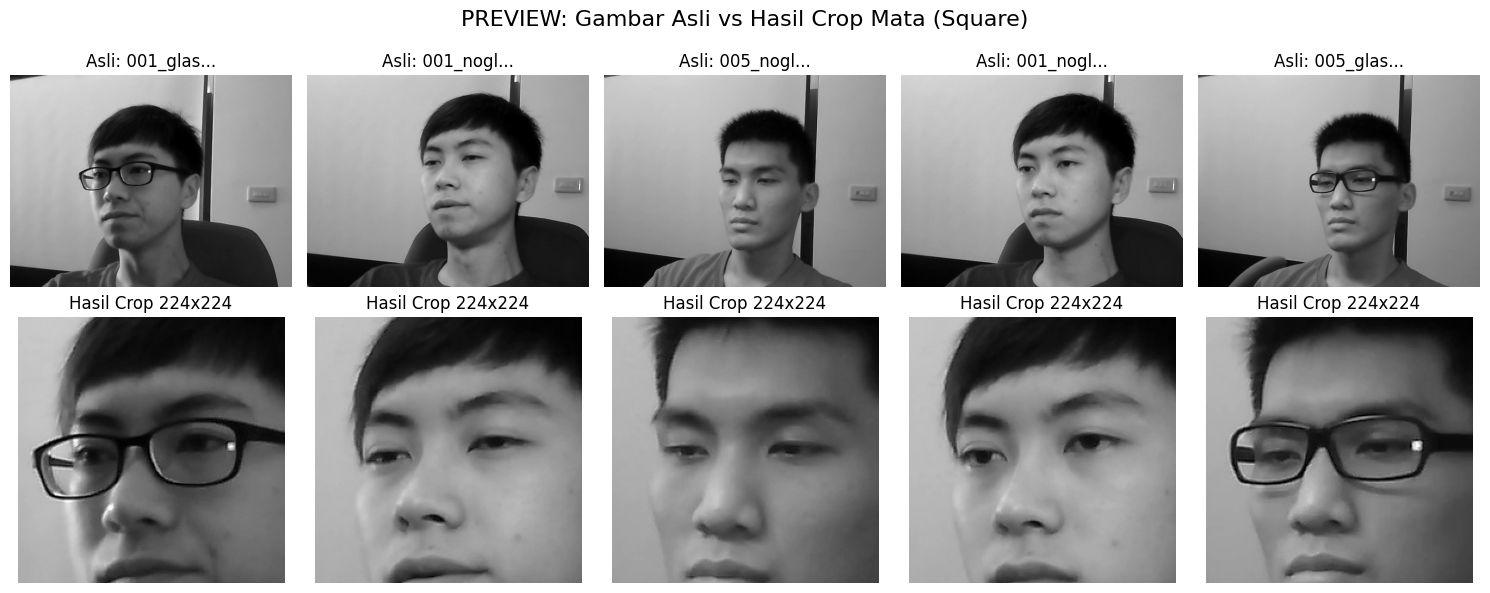

In [11]:
# ==========================================
# DEBUG: TAMPILKAN 5 CONTOH HASIL CROP MATA
# ==========================================
import matplotlib.pyplot as plt
import random

def debug_show_5_crops(input_base):
    # Kita ambil sampel dari folder train/drowsy saja
    sample_dir = os.path.join(input_base, "train", "drowsy")
    
    if not os.path.exists(sample_dir):
        print(f"Folder tidak ditemukan: {sample_dir}")
        return
        
    all_files = [f for f in os.listdir(sample_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    # Ambil 5 file secara acak
    sample_files = random.sample(all_files, min(5, len(all_files)))
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle("PREVIEW: Gambar Asli vs Hasil Crop Mata (Square)", fontsize=16)
    
    for i, img_name in enumerate(sample_files):
        img_path = os.path.join(sample_dir, img_name)
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape
        
        # 1. Tampilkan Gambar Asli di baris atas
        axes[0, i].imshow(img_rgb)
        axes[0, i].set_title(f"Asli: {img_name[:8]}...")
        axes[0, i].axis('off')
        
        # Proses MediaPipe
        results = face_mesh.process(img_rgb)
        
        if results.multi_face_landmarks:
            landmarks = results.multi_face_landmarks[0]
            
            # Panggil fungsi crop kotak (margin ratio 0.8 bisa diubah kalau masih terlalu sempit/lebar)
            x1, y1, x2, y2 = get_square_bounding_box(img_rgb, landmarks, w, h, margin_ratio=0.8)
            
            # Pastikan kordinat valid
            if x2 > x1 and y2 > y1:
                # Crop
                cropped = img_rgb[y1:y2, x1:x2]
                
                # Resize ke 224x224
                pil_img = Image.fromarray(cropped).resize(TARGET_SIZE, Image.Resampling.LANCZOS)
                
                # 2. Tampilkan Hasil Crop di baris bawah
                axes[1, i].imshow(pil_img)
                axes[1, i].set_title("Hasil Crop 224x224")
                axes[1, i].axis('off')
            else:
                axes[1, i].text(0.5, 0.5, 'Kordinat Error', ha='center', va='center')
                axes[1, i].axis('off')
        else:
            axes[1, i].text(0.5, 0.5, 'Wajah Tak Terdeteksi', ha='center', va='center')
            axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# Jalankan fungsi debug
debug_show_5_crops(INPUT_DIR)
